# Bongcloud Data

Monthly count of Lichess games that reached the position after **1.e4 e5 2.Ke2**.

`lichess_api_data.json` comes from the Opening Explorer. Each `history` entry is a month with
three *outcome* counts — `white`, `draws`, `black` — so the number of games that
reached the position is their sum.

Fetched from API call below
```
https://explorer.lichess.ovh/lichess?variant=standard&play=e2e4,e7e5,e1e2&speeds=blitz&ratings=0,1000,1200,1400,1600,1800,2000,2200,2500,2700&history=true&moves=0&topGames=0&recentGames=0
```

In [27]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open("lichess_api_data.json") as f:
    data = json.load(f)

bongcloud_df = pd.DataFrame(data["history"])
bongcloud_df["games"] = bongcloud_df["white"] + bongcloud_df["draws"] + bongcloud_df["black"]
bongcloud_df["month"] = pd.to_datetime(bongcloud_df["month"])
bongcloud_df = bongcloud_df.sort_values("month")
bongcloud_df.head(5)


,month,white,draws,black,games
0,2013-01-01,0,0,1,1
1,2013-02-01,0,1,0,1
2,2013-03-01,0,0,0,0
3,2013-04-01,0,0,1,1
4,2013-05-01,0,0,0,0


In [28]:
march_total = bongcloud_df.loc[bongcloud_df["month"] == "2021-03-01", "games"].sum()
print(f"Total games in March: {march_total}")

Total games in March: 5031


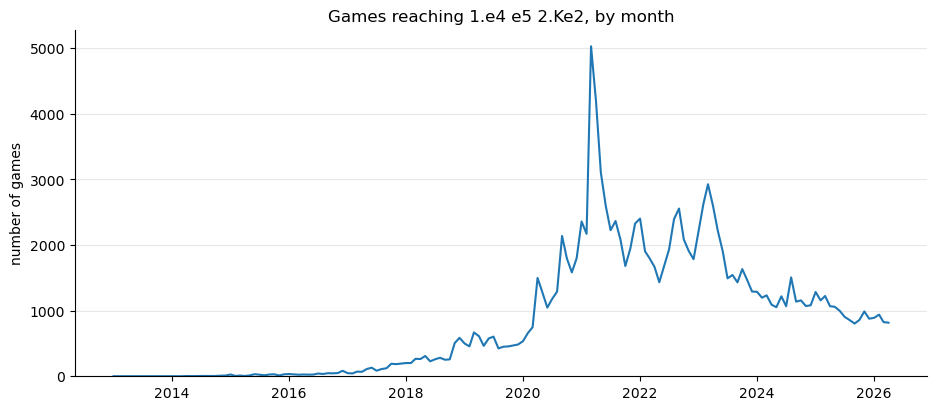

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(bongcloud_df["month"], bongcloud_df["games"], linewidth=1.5)

ax.set_ylabel("number of games")
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# write file to figures directory
plt.savefig("figures/bongcloud_games.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
# Original dataa source: https://database.lichess.org/
bongcloud_data = pd.read_csv("lichess_db_bongcloud_2021-03.csv")
bongcloud_data.info()   

# get all games where bke7=1
bongcloud_games_with_bke7 = bongcloud_data[bongcloud_data['bke7'] == 1]
print(f"Number of games where Black played 2...Ke7: {len(bongcloud_games_with_bke7)}")


# print number of rows where opening = "Bongcloud Attack"
bongcloud_games = bongcloud_data[bongcloud_data['opening'] == "Bongcloud Attack"]
print(f"Number of games where opening is Bongcloud Attack: {len(bongcloud_games)}")
print(f"Number of games from lichess history API endpoint: {bongcloud_df['games'].sum()}")
bongcloud_games_with_bke7.to_csv("double_bongcloud.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5068 entries, 0 to 5067
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       5068 non-null   object
 1   white      5068 non-null   object
 2   white_elo  5068 non-null   int64 
 3   black      5068 non-null   object
 4   black_elo  5068 non-null   int64 
 5   e4e5       5068 non-null   int64 
 6   wke2       5068 non-null   int64 
 7   bke7       5068 non-null   int64 
 8   opening    5068 non-null   object
 9   moves      5068 non-null   object
dtypes: int64(5), object(5)
memory usage: 396.1+ KB
Number of games where Black played 2...Ke7: 324
Number of games where opening is Bongcloud Attack: 5068
Number of games from lichess history API endpoint: 5435


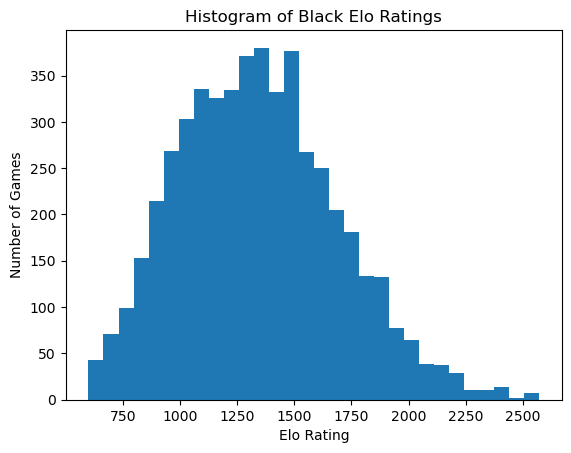

Mean of black_elo: 1342.5627466456197
Lowest rating of black_elo: 600
Highest rating of black_elo: 2572


In [24]:
# plot histogram of white_elo
plt.hist(bongcloud_data['black_elo'], bins=30)

plt.title('Histogram of Black Elo Ratings')
plt.xlabel('Elo Rating')
plt.ylabel('Number of Games')
# save the plot
plt.savefig("figures/black_elo_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Mean of black_elo: {bongcloud_data['black_elo'].mean()}")
print(f"Lowest rating of black_elo: {bongcloud_data['black_elo'].min()}")
print(f"Highest rating of black_elo: {bongcloud_data['black_elo'].max()}")